In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

df = pd.read_csv('eval/model_vs_labels.csv')
df['match'] = df['label_sentiment'] == df['model_sentiment']
print(f"Total comments: {len(df)}")
print(f"Sentiment matches: {df['match'].sum()} / {len(df)} ({df['match'].mean():.1%})")

Total comments: 71
Sentiment matches: 55 / 71 (77.5%)


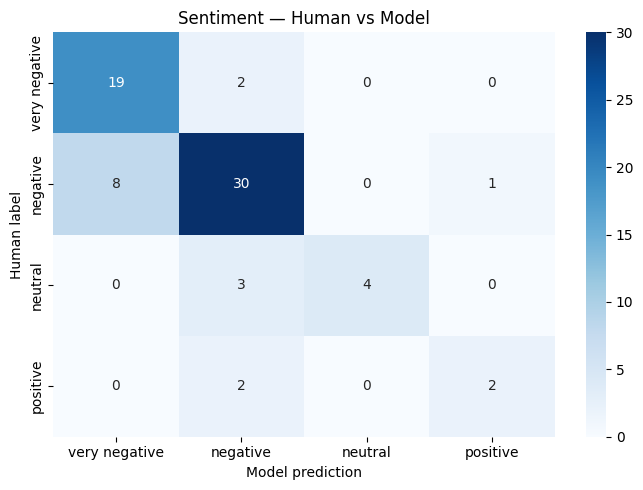

In [2]:
# Confusion matrix
labels = ['very negative', 'negative', 'neutral', 'positive', 'very positive']
present = [l for l in labels if l in df['label_sentiment'].values or l in df['model_sentiment'].values]

cm = confusion_matrix(df['label_sentiment'], df['model_sentiment'], labels=present)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present, yticklabels=present, ax=ax)
ax.set_xlabel('Model prediction')
ax.set_ylabel('Human label')
ax.set_title('Sentiment — Human vs Model')
plt.tight_layout()
plt.show()

In [3]:
# Full comparison table — all 58 comments
view = df[['comments', 'label_sentiment', 'model_sentiment', 'match', '_annotator', 'label_tickers']].copy()
view['comments'] = view['comments'].str[:120] + '...'

def color_row(row):
    bg = 'background-color: #d4edda' if row['match'] else 'background-color: #f8d7da'
    return [bg] * len(row)

pd.set_option('display.max_colwidth', 120)
view.style.apply(color_row, axis=1)

,comments,label_sentiment,model_sentiment,match,_annotator,label_tickers
0,"Not only is he able to do that, but when he took over Chipotle in 2018 he uprooted the entire corporation from Denver an...",negative,negative,True,nan,CMG
1,Time to sell my TSLA stock....,negative,negative,True,nan,TSLA
2,[https://investor.gm.com/news-releases/news-release-details/gm-board-approves-new-6-billion-share-repurchase-authorizati...,negative,positive,False,nan,GM
3,Just sent an email to Starbucks through their Contact Us online. It’s a pain in the ass to get to. “Hello l’d like to le...,negative,very negative,False,nan,SBUX
4,"The local Chipotle has a lot of 1-star reviews lately. They all mention the same thing - lack of cleanliness, and extre...",negative,negative,True,nan,CMG
5,DAMN!!! Chipotle invoked the wrath of Keith Lee.....HANG IT UP!!!!! SHEESH!!!!...,negative,very negative,False,nan,CMG
6,"Reminds me of this from August 24, 2016 in the Augusta Chronicle: > CHARLESTON, W.Va. - U.S. Sen. Joe Manchin remained ...",negative,negative,True,Jovan_B4,VTRS
7,I work at one of the MANY Kroger owned companies: Baker’s City Market Dillons Food 4 Less Foods Co Fred Meyer Fry...,very negative,very negative,True,Jovan_B4,KR
8,Isn't it crazy that a company can remain clueless about their issues while they are literally spelled out on the front p...,very negative,very negative,True,Jovan_B4,CMG
9,I’m a Tesla shareholder and there is no world where Elon musk should get that much...,negative,negative,True,Jovan_B4,TSL


In [4]:
# Mismatches only — full comment text
mismatches = df[~df['match']][['comments', 'label_sentiment', 'model_sentiment', '_annotator', 'label_tickers']].copy()
print(f"{len(mismatches)} mismatches out of {len(df)} comments\n")

for i, row in mismatches.iterrows():
    print(f"--- #{i} | Human: {row['label_sentiment']} | Model: {row['model_sentiment']} | Labeled by: {row['_annotator']} ---")
    print(row['comments'][:500])
    print()

16 mismatches out of 71 comments

--- #2 | Human: negative | Model: positive | Labeled by: nan ---
[https://investor.gm.com/news-releases/news-release-details/gm-board-approves-new-6-billion-share-repurchase-authorization](https://investor.gm.com/news-releases/news-release-details/gm-board-approves-new-6-billion-share-repurchase-authorization)



`GM Board Approves New $6 Billion Share Repurchase Authorization`

`Tue, June 11, 2024`

`DETROIT, June 11, 2024 /PRNewswire/ --General Motors Co.(NYSE:GM) announced today that its Board of Directors has approved a new share repurchase authorization 

--- #3 | Human: negative | Model: very negative | Labeled by: nan ---
Just sent an email to Starbucks through their Contact Us online. It’s a pain in the ass to get to.
“Hello l’d like to leave feedback concerning your incoming CEO Brian Niccol and the decision to allow him to emit over 2000lbs of carbon per month into our atmosphere in order to commute from Southern California to Seattle on a we

In [5]:
# Per-annotator accuracy — who agrees most with the model?
per_annotator = df.groupby('_annotator')['match'].agg(['sum', 'count'])
per_annotator['accuracy'] = per_annotator['sum'] / per_annotator['count']
per_annotator.columns = ['correct', 'total', 'accuracy']
per_annotator['accuracy'] = per_annotator['accuracy'].map('{:.1%}'.format)
print(per_annotator.sort_values('correct', ascending=False))

                   correct  total accuracy
_annotator                                
Pierpaolo_labeled        9     13    69.2%
Jovan_labeled            8     10    80.0%
Francesco_labeled        8      8   100.0%
Jovan_B5_labeled         7      9    77.8%
Jovan_B4                 7      8    87.5%
Sergio_labeled           7      9    77.8%
Alice_labeled            6      8    75.0%


In [6]:
simple = df[['comments', 'label_sentiment', 'model_sentiment',
  '_annotator']].copy()
simple.columns = ['comment', 'human_label', 'llm_label', 'annotator']
simple['comment'] = simple['comment'].str[:150] + '...'
simple

,comment,human_label,llm_label,annotator
0,"Not only is he able to do that, but when he took over Chipotle in 2018 he uprooted the entire corporation from Denve...",negative,negative,NaN
1,Time to sell my TSLA stock....,negative,negative,NaN
2,[https://investor.gm.com/news-releases/news-release-details/gm-board-approves-new-6-billion-share-repurchase-authori...,negative,positive,NaN
3,Just sent an email to Starbucks through their Contact Us online. It’s a pain in the ass to get to.\n“Hello l’d like ...,negative,very negative,NaN
4,"The local Chipotle has a lot of 1-star reviews lately. They all mention the same thing - lack of cleanliness, and e...",negative,negative,NaN
...,...,...,...,...
66,"Dude...they stole my chipotle bowl. I got the order in person, then kept it on table to pick up online order, i wa...",very negative,very negative,Jovan_labeled
67,Last time I went to a Chipotle they had different cups/spoons for the meats and beans that were noticeably way small...,negative,negative,Jovan_labeled
68,Cause money people don't understand the fucking reality of McDonald's and fast food. You can't charge sit down price...,negative,very negative,Jovan_labeled
69,Novo's market capitalization of $570 billion (Jesus Christ) is bigger than the Danish economy. You read that right....,very negative,very negative,Jovan_labeled


## Export — v1 Baseline Artifacts
Run this section to save versioned PNG + CSV snapshots for the presentation.
After tuning the SYSTEM_PROMPT, re-run `score_eval.py --run-model`, update
the CSV path below to `v2_`, and re-run to get the comparison artifacts.

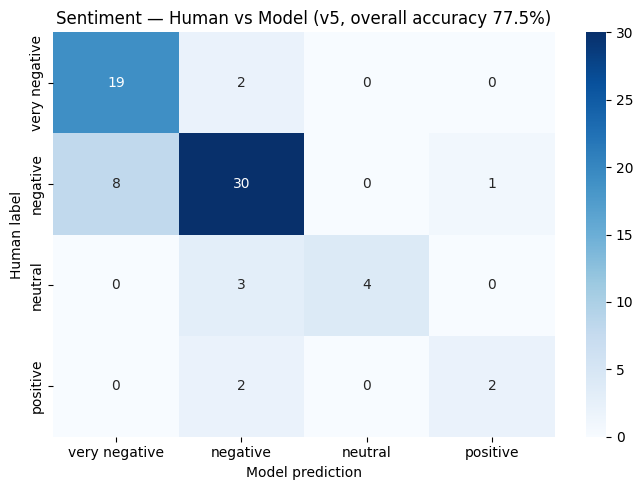

Saved: eval/v5_confusion_matrix.png


In [7]:
from pathlib import Path
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.metrics import confusion_matrix

VERSION = 'v5'  # change to 'v2', 'v3', etc. after each tuning round
EVAL_DIR = Path('eval')

df = pd.read_csv('eval/model_vs_labels.csv')
df['match'] = df['label_sentiment'] == df['model_sentiment']

LABEL_ORDER = ['very negative', 'negative', 'neutral', 'positive', 'very positive']
present = [l for l in LABEL_ORDER
           if l in df['label_sentiment'].values or l in df['model_sentiment'].values]

# ── 1. Confusion matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(df['label_sentiment'], df['model_sentiment'], labels=present)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present, yticklabels=present, ax=ax)
ax.set_xlabel('Model prediction')
ax.set_ylabel('Human label')
accuracy = df['match'].mean()
ax.set_title(f'Sentiment — Human vs Model ({VERSION}, overall accuracy {accuracy:.1%})')
plt.tight_layout()
out = EVAL_DIR / f'{VERSION}_confusion_matrix.png'
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out}')


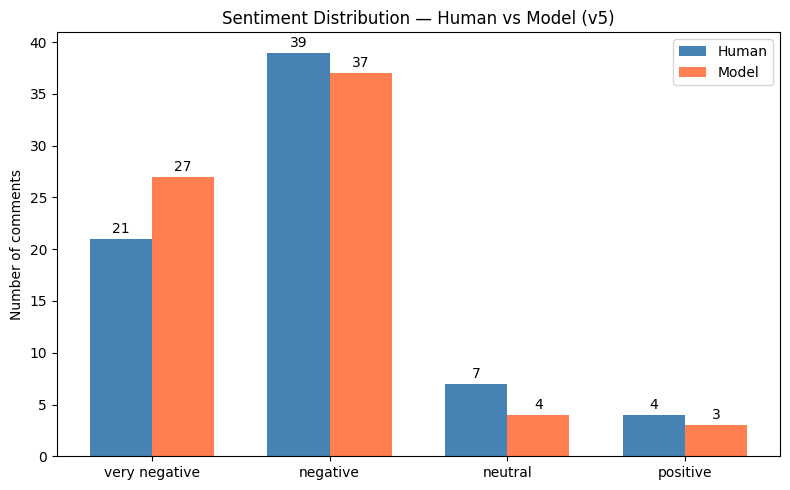

Saved: eval/v5_sentiment_distribution.png


In [8]:
# ── 2. Sentiment distribution: human vs model ────────────────────────────────
human_counts = df['label_sentiment'].value_counts().reindex(present, fill_value=0)
model_counts = df['model_sentiment'].value_counts().reindex(present, fill_value=0)

x = range(len(present))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([i - width/2 for i in x], human_counts, width, label='Human', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], model_counts, width, label='Model', color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(present)
ax.set_ylabel('Number of comments')
ax.set_title(f'Sentiment Distribution — Human vs Model ({VERSION})')
ax.legend()
ax.bar_label(bars1, padding=2)
ax.bar_label(bars2, padding=2)
plt.tight_layout()
out = EVAL_DIR / f'{VERSION}_sentiment_distribution.png'
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out}')


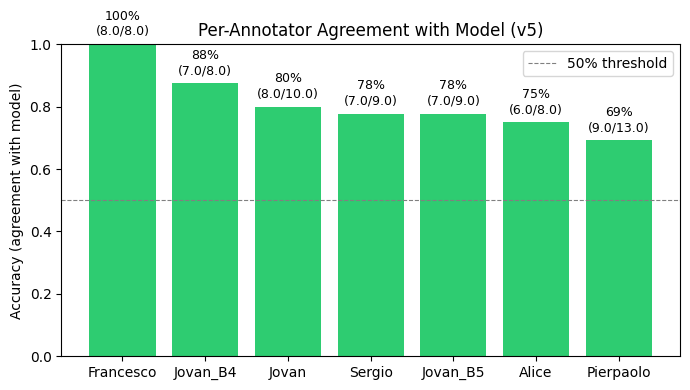

Saved: eval/v5_per_annotator_accuracy.png


In [9]:
# ── 3. Per-annotator accuracy bar chart ──────────────────────────────────────
per_ann = (df.groupby('_annotator')['match']
             .agg(correct='sum', total='count')
             .assign(accuracy=lambda x: x['correct'] / x['total'])
             .sort_values('accuracy', ascending=False))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ecc71' if v >= 0.5 else '#e74c3c' if v < 0.25 else '#f39c12'
          for v in per_ann['accuracy']]
bars = ax.bar(per_ann.index.str.replace('_labeled', ''), per_ann['accuracy'], color=colors)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy (agreement with model)')
ax.set_title(f'Per-Annotator Agreement with Model ({VERSION})')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50% threshold')
ax.legend()
for bar, (_, row) in zip(bars, per_ann.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{row['accuracy']:.0%}\n({row['correct']}/{row['total']})",
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
out = EVAL_DIR / f'{VERSION}_per_annotator_accuracy.png'
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out}')


In [10]:
# ── 4. Classification report CSV (precision / recall / F1 per class) ─────────
report = classification_report(
    df['label_sentiment'], df['model_sentiment'],
    labels=present, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report).T.round(3)
out = EVAL_DIR / f'{VERSION}_classification_report.csv'
report_df.to_csv(out)
print(f'Saved: {out}')
print(report_df.to_string())


Saved: eval/v5_classification_report.csv
               precision  recall  f1-score  support
very negative      0.704   0.905     0.792   21.000
negative           0.811   0.769     0.789   39.000
neutral            1.000   0.571     0.727    7.000
positive           0.667   0.500     0.571    4.000
accuracy           0.775   0.775     0.775    0.775
macro avg          0.795   0.686     0.720   71.000
weighted avg       0.790   0.775     0.772   71.000
